# Algo 3: Unified Inference with Disentangled Rejection

## CICIoT2023 | Reuse Day-16 Checkpoint + L_φ | Reuse Day-19 q | Target (y) = "label_multiclass" | Data Reupload = 2 | ... X_val, X_cal, X_test, X_zero Samples

## $ ρ(x) \rightarrow F_{c} \rightarrow s=1−F_{max} \rightarrow \text{conformal} \rightarrow \text{label} + \text{certified radius} $

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_ALPHA, DEFAULT_BATCH_SIZE, DEFAULT_CF, DEFAULT_LAMBDA1, DEFAULT_LAMBDA2,
    DEFAULT_LR, DEFAULT_NOISE_RATE, ZERO_DAY, DEFAULT_SEED
)
from scripts.data import (
    capped_sample, load_split,
    plot_class_balance_pie, stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.conformal import calibrate_threshold
from scripts.prototypes import prototype_summary
from scripts.logging import write_history_log
from scripts.inference import qsnet_infer_batch, qsnet_infer_single, estimate_lipschitz
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y
from scripts.theory import analytic_lipschitz_bound, estimate_lipschitz_percentile, check_lipschitz_tightness

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [4]:
NOTEBOOK_NAME = "22.e2e-algo3_ciciot2023.ipynb"
DAY16_NOTEBOOK = "16.estimate-lipschitz_ciciot2023"
DAY19_NOTEBOOK = "19.fgsm-pgd-robustness_ciciot2023"

dataset = "CICIoT2023"
data_path = f"data/{dataset}/quantum"
target_col = "label_multiclass"
split_prefix = "q8"

torch.manual_seed(42)
np.random.seed(42)

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [8]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, f"{split_prefix}_val", target_col, class_names)
X_cal_full, y_cal_full = load_split(data_path, f"{split_prefix}_calibration", target_col, class_names)
X_test_full, y_test_full = load_split(data_path, f"{split_prefix}_test", target_col, class_names)
X_zero_full, y_zero_full = load_split(data_path, f"{split_prefix}_zeroday", target_col, class_names)

# check shape
print(f"train : {X_train_full.shape, y_train_full.shape}\n\
val   : {X_val_full.shape, y_val_full.shape}\n\
cal   : {X_cal_full.shape, y_cal_full.shape}\n\
test  : {X_test_full.shape, y_test_full.shape}\n\
zero  : {X_zero_full.shape, y_zero_full.shape}"
)

train : ((132166, 8), (132166,))
val   : ((18883, 8), (18883,))
cal   : ((18883, 8), (18883,))
test  : ((18883, 8), (18883,))
zero  : ((10984, 8), (10984,))


## EDA (Before Subset)

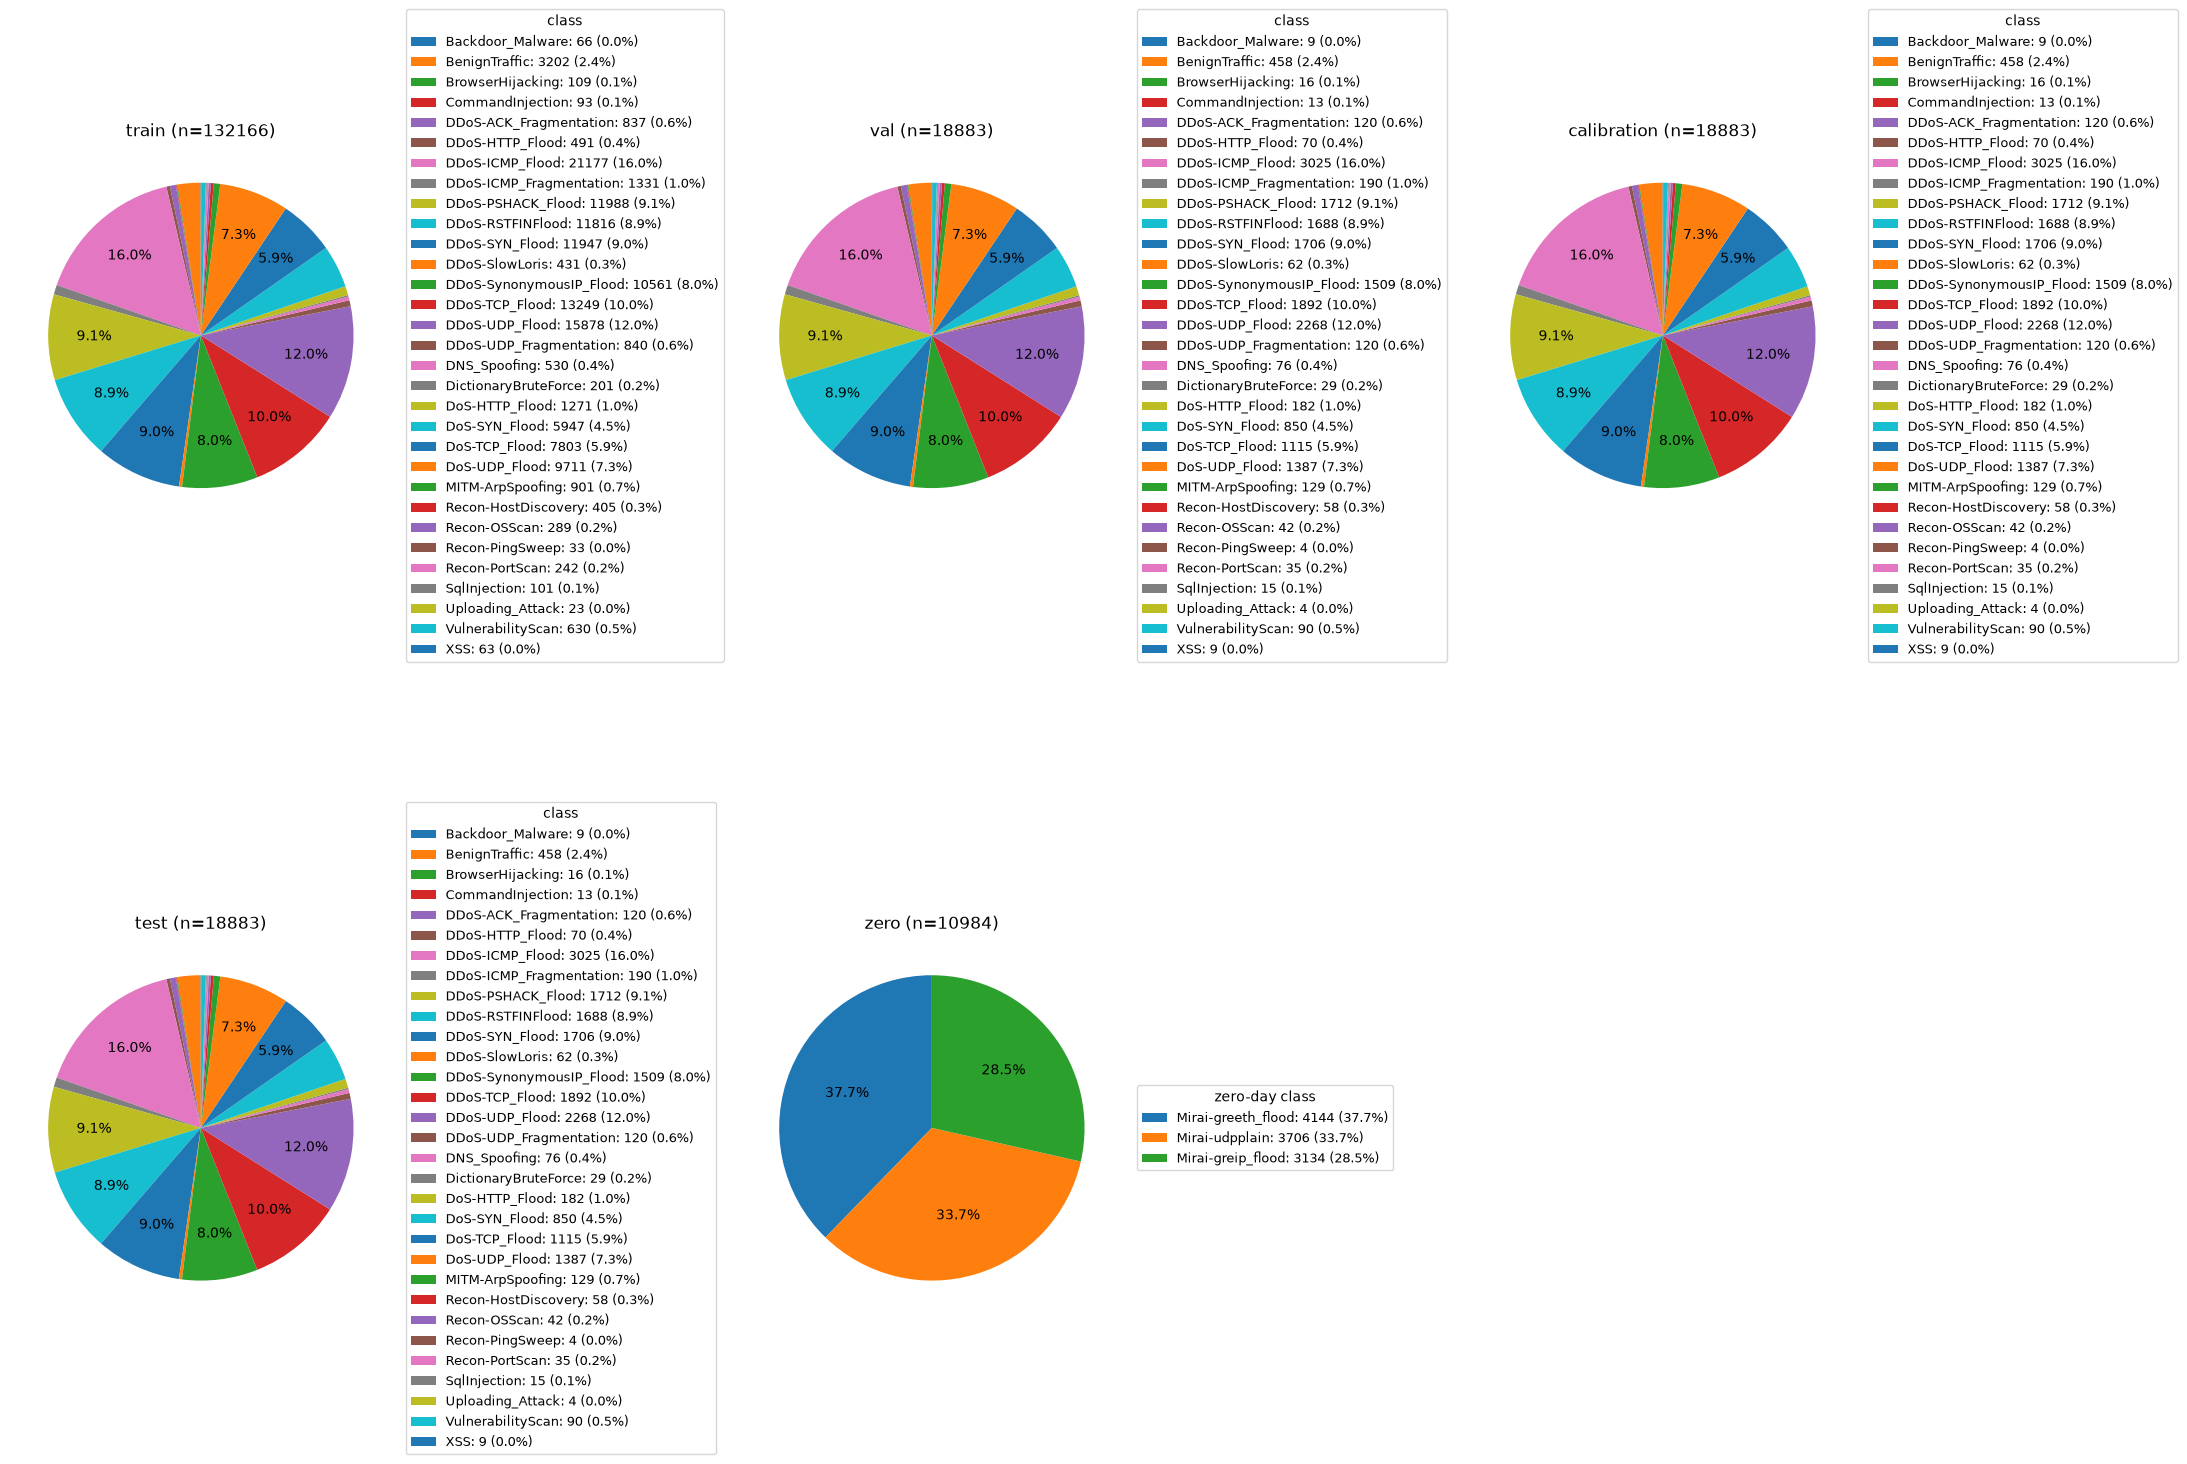

In [9]:
splits = {
    "train": y_train_full,
    "val": y_val_full,
    "calibration": y_cal_full,
    "test": y_test_full,
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

## reload just for EDA
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero = df_zero[df_zero[target_col].notna()].reset_index(drop=True)

vc = df_zero[target_col].value_counts()
ax.pie(vc.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 1 else "", startangle=90)
ax.legend(
    [f"{lab}: {n} ({100*n/vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

# remove extra chart
for ax in axes[len(splits) + 1:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Data Subset

In [10]:
SUBSET = True  # set to False for the full dataset
MORE_SUBSET = True
SEED = 42
PER_CLASS_CAP = 100  # matches Day-16 CICIoT protocol

In [11]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

if MORE_SUBSET is True:
    X_val, y_val = stratified_head(X_val_full, y_val_full, 100, seed=SEED)
    X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 100, seed=SEED)
    X_test, y_test = stratified_head(X_test_full, y_test_full, 100, seed=SEED)
    X_zero, y_zero, idx_zero = stratified_head(X_zero_full, y_zero_full, 100, seed=SEED, return_index=True)
else:
    X_val, y_val = X_val_full, y_val_full
    X_cal, y_cal = X_cal_full, y_cal_full
    X_test, y_test = X_test_full, y_test_full
    X_zero, y_zero = X_zero_full, y_zero_full
    idx_zero = np.arange(len(X_zero))

# check shape
print(f"train : {X_train.shape, y_train.shape}\n\
val   : {X_val.shape, y_val.shape}\n\
cal   : {X_cal.shape, y_cal.shape}\n\
test  : {X_test.shape, y_test.shape}\n\
zero  : {X_zero.shape, y_zero.shape}"
)

train : ((2878, 8), (2878,))
val   : ((100, 8), (100,))
cal   : ((100, 8), (100,))
test  : ((100, 8), (100,))
zero  : ((100, 8), (100,))


## EDA (After Subset)

In [12]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 31
number of qubits: 8


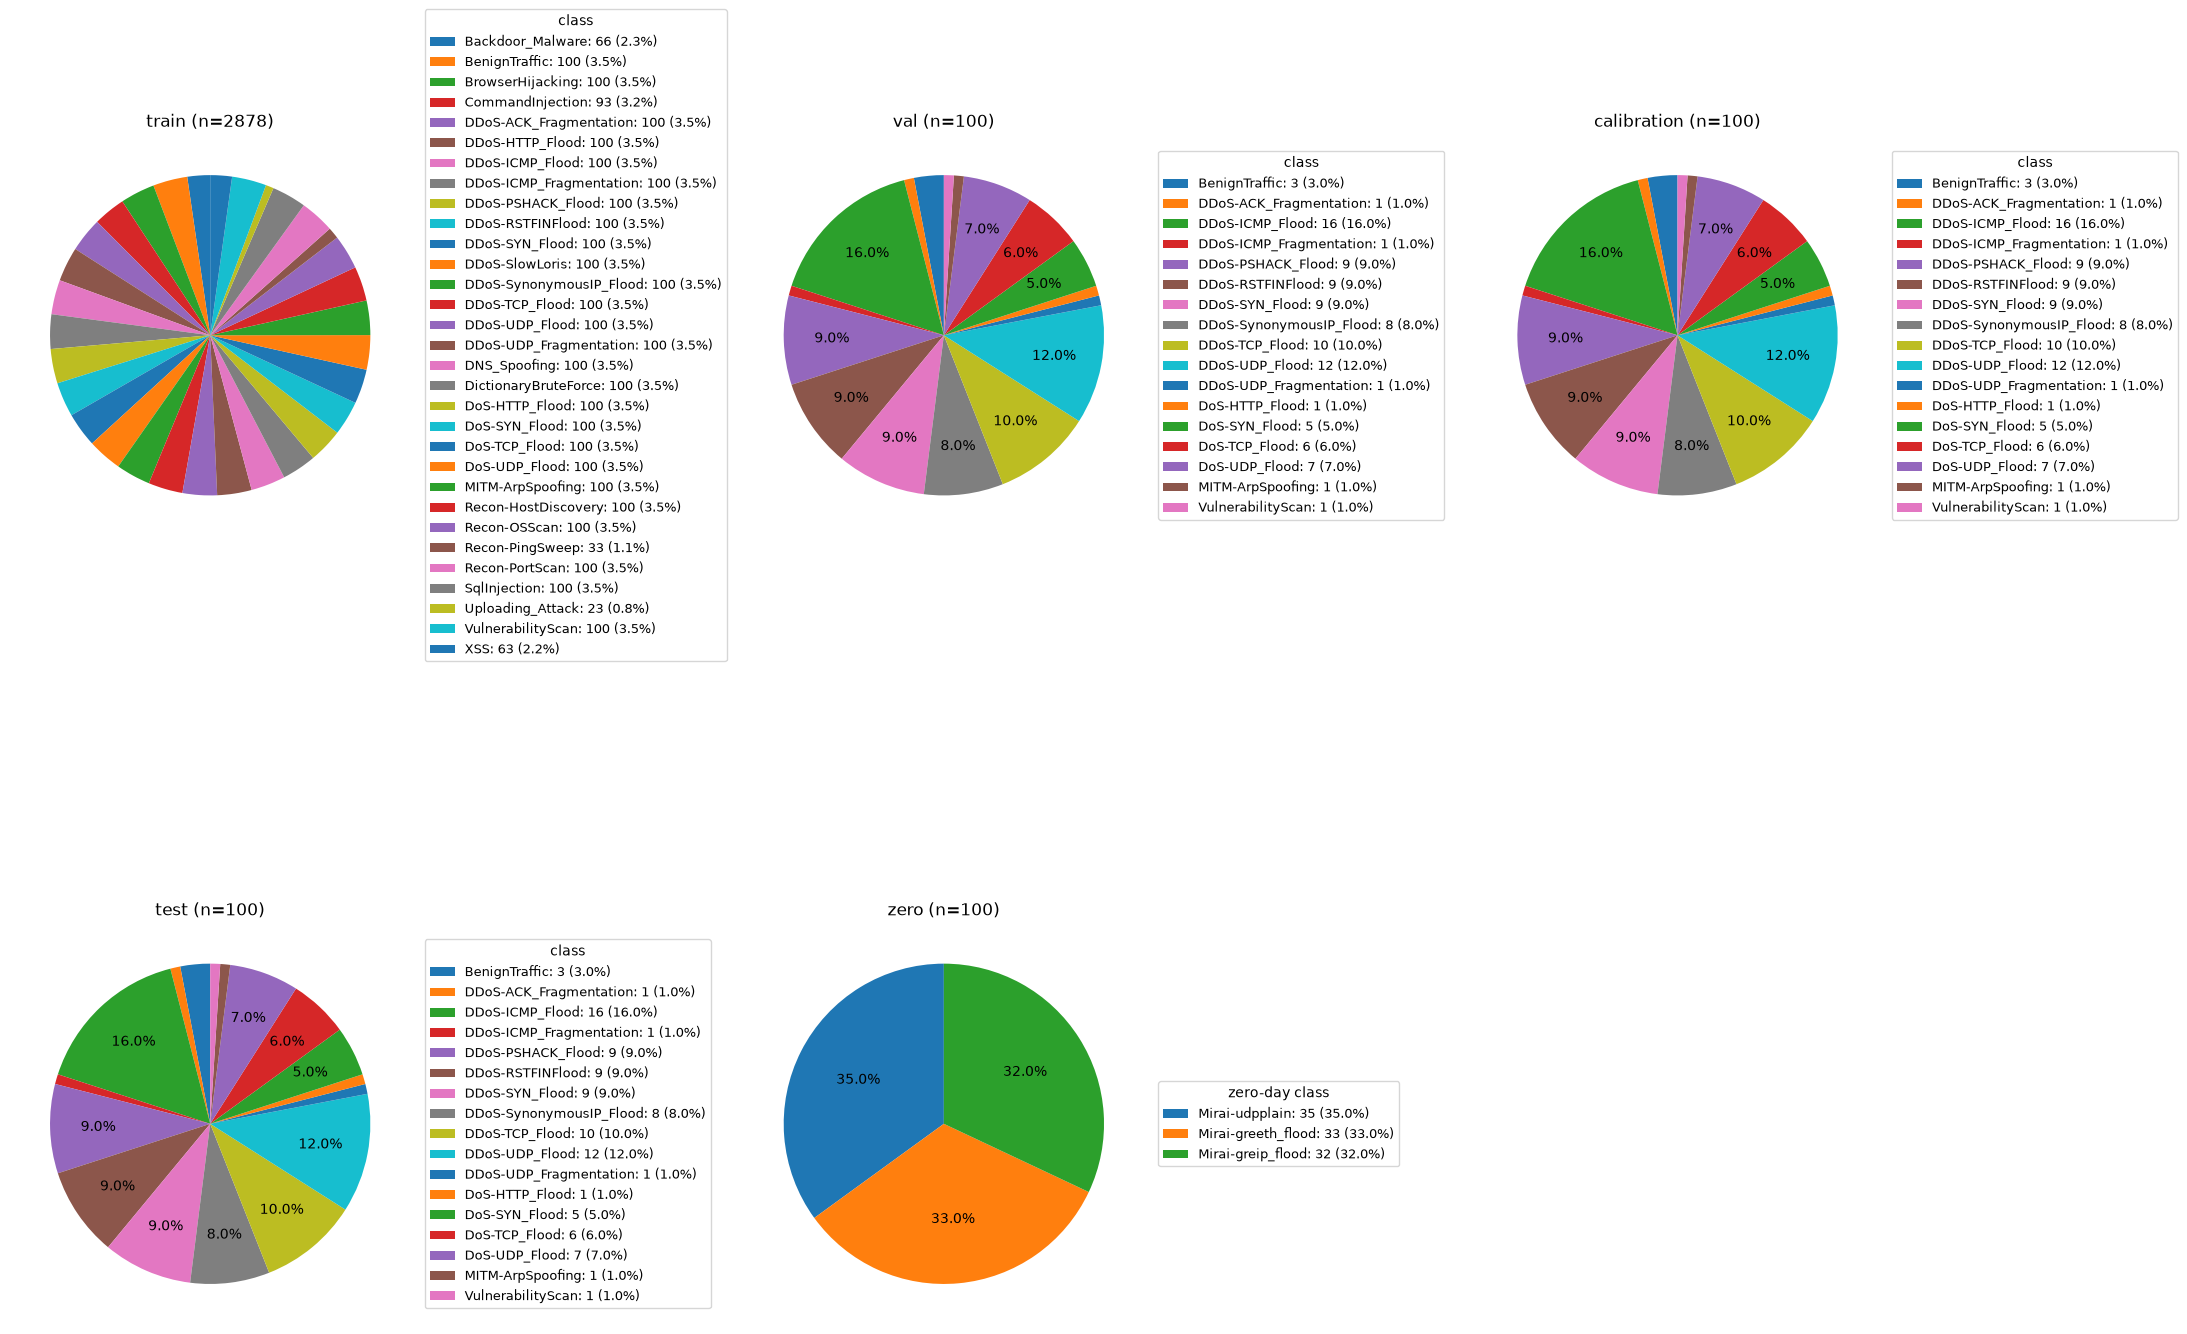

In [13]:
splits = {
    "train": y_train,
    "val": y_val,
    "calibration": y_cal,
    "test": y_test,
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero)

## reload just for EDA
df_zero_subset = df_zero.reset_index(drop=True).iloc[idx_zero]
vc = df_zero_subset[target_col].value_counts()
ax.pie(vc.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 1 else "", startangle=90)
ax.legend(
    [f"{lab}: {n} ({100*n/vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero_subset)})")

# remove extra chart
for ax in axes[len(splits) + 1:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [14]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [15]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Load Day-16 Encoder + $L_\varphi$

This notebook reuses the Day-16 MAQT checkpoint ($\theta^\star$, prototypes) and the published $L_\varphi$ artifact.

Set `LOAD_CHECKPOINT = False` only to retrain as a fallback.

In [16]:
# Day-16 model checkpoint
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY16_NOTEBOOK}-checkpoint.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2
seed = DEFAULT_SEED # 42

In [17]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))

    # rebuild circuit if checkpoint meta differs
    forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train, y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

loaded checkpoint: models/prototypes/CICIoT2023/16.estimate-lipschitz_ciciot2023-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 31


In [18]:
# Day-16 L_phi (required for eps*)
LOAD_LPHI = True
LPHI_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY16_NOTEBOOK}-lphi.pt",
]

n_pairs = 200
percentile = 95

In [19]:
lphi_path = next((p for p in LPHI_CANDIDATES if p.exists()), None)

if LOAD_LPHI and lphi_path is not None:
    lphi_art = torch.load(lphi_path, map_location="cpu", weights_only=False)
    L_phi_estimated = float(lphi_art["L_phi_estimated"])
    L_phi_analytic = float(lphi_art["L_phi_analytic"])
    L_phi_percentile = float(lphi_art["L_phi_percentile"])

    # prefer analytic R/2 bound for L_phi
    L_phi = L_phi_analytic if np.isfinite(L_phi_analytic) else L_phi_estimated
    print(f"loaded L_phi from: {lphi_path}")
    print(f"L_phi analytic={L_phi_analytic:.4f} | estimated(p{L_phi_percentile:g})={L_phi_estimated:.4f}")
else:
    print("ERROR: cannot load L_phi as artifact is missing!")
    # certificate
    L_phi = analytic_lipschitz_bound(num_layers, reupload=True)

    # diagnostic (optional)
    # tightness_diagnostic = estimate_lipschitz_percentile(
    #     X_train, theta_star, forward_circuit,
    #     n_pairs=n_pairs, device=device, percentile=percentile, seed=seed,
    # )
    # print(check_lipschitz_tightness(diag, L_phi))

print(f"using L_phi={L_phi:.4f} for certified radius")

loaded L_phi from: models/prototypes/CICIoT2023/16.estimate-lipschitz_ciciot2023-lphi.pt
L_phi analytic=1.0000 | estimated(p95)=0.6600
using L_phi=1.0000 for certified radius


## Load Day-19 Conformal Zero-Day Threshold Calibration (q)

- Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.
- Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

This notebook reuses the Day-19 artifact.

Set `LOAD_Q = False` only to recalibrate $q$ as a fallback.

In [20]:
# Day-19 artifact
LOAD_Q = True
Q_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY19_NOTEBOOK}-artifact.pt",
]

alpha = DEFAULT_ALPHA

In [21]:
q_path = next((p for p in Q_CANDIDATES if p.exists()), None)
q_source = None
scores_sorted = None

if LOAD_Q and q_path is not None:
    day19 = torch.load(q_path, map_location="cpu", weights_only=False)
    q = float(day19["q"])
    alpha = float(day19["alpha"])
    q_source = str(q_path)
    print(f"loaded q from Day-19: q={q:.6f} (alpha={alpha})")
else:
    print("ERROR: cannot load q as artifact is missing; recalibrating q on X_cal")
    q, scores_sorted = calibrate_threshold(
        theta_star, X_cal, prototypes, forward_circuit,
        alpha=alpha, device=device, batch_size=batch_size,
    )
    q_source = "just calibrated with calibrate_threshold(X_cal)"
    print(f"calibrated q={q:.6f} (alpha={alpha}, n_cal={len(X_cal)})")

loaded q from Day-19: q=0.316259 (alpha=0.05)


## Evaluation on Known Test Samples

In [22]:
Cf = DEFAULT_CF
zero_day = ZERO_DAY
p = noise_rate

print(f"p       : {p}")
print(f"L_phi   : {L_phi:.4f}")
print(f"C_f     : {Cf}")
print(f"q       : {q:.6f}")

p       : 0.01
L_phi   : 1.0000
C_f     : 1.0
q       : 0.316259


In [23]:
y_pred, radii, novelty_scores, f_maps = qsnet_infer_batch(
    X_test, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)
y_test_np = to_np_y(y_test).astype(int)
label_ids = list(range(num_classes))

[pipeline] rejection rate on test: 0.0300
[pipeline] accepted known-sample test accuracy: 0.4742
[pipeline] accepted known-sample test macro-F1: 0.1670
[pipeline] accepted known-sample mean certified radius: 0.0137

[pipeline] classification report (accepted only):
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.00      0.00      0.00         2
       BrowserHijacking       0.00      0.00      0.00         0
       CommandInjection       0.00      0.00      0.00         0
 DDoS-ACK_Fragmentation       1.00      1.00      1.00         1
        DDoS-HTTP_Flood       0.00      0.00      0.00         0
        DDoS-ICMP_Flood       0.64      1.00      0.78        16
DDoS-ICMP_Fragmentation       0.33      1.00      0.50         1
      DDoS-PSHACK_Flood       1.00      0.78      0.88         9
       DDoS-RSTFINFlood       0.00      0.00      0.00         9
         DDoS-SYN_

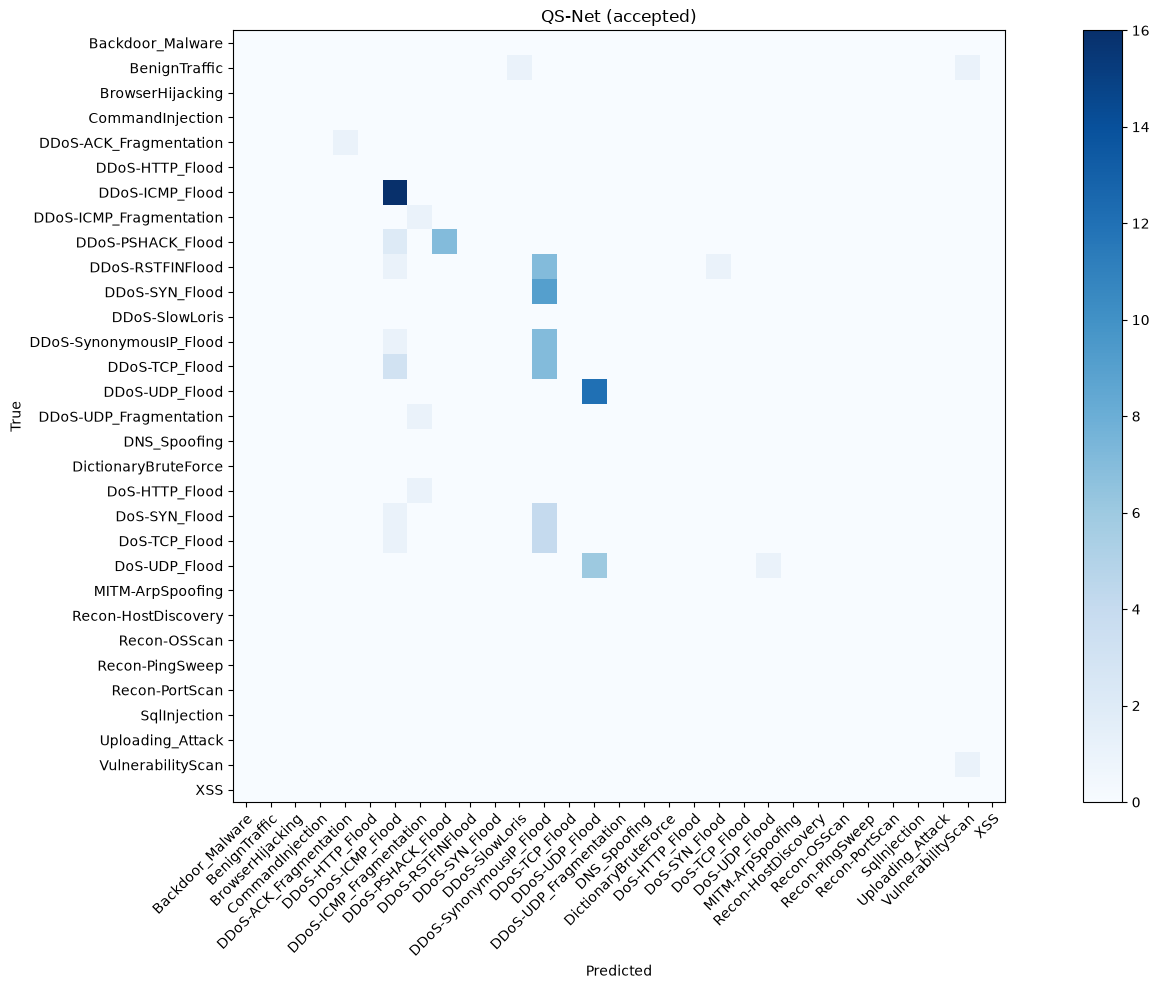

In [24]:
known_mask = y_pred != ZERO_DAY
pipeline_reject_rate = float(1.0 - known_mask.mean())
pipeline_acc = float(np.mean(y_pred[known_mask] == y_test_np[known_mask])) if known_mask.any() else 0.0
pipeline_macro_f1 = float(
    f1_score(y_test_np[known_mask], y_pred[known_mask], average="macro", labels=label_ids, zero_division=0)
)
pipeline_radius_mean = float(radii[known_mask].mean()) if known_mask.any() else float('nan')

print(f"[pipeline] rejection rate on test: {pipeline_reject_rate:.4f}")
print(f"[pipeline] accepted known-sample test accuracy: {pipeline_acc:.4f}")
print(f"[pipeline] accepted known-sample test macro-F1: {pipeline_macro_f1:.4f}")
print(f"[pipeline] accepted known-sample mean certified radius: {pipeline_radius_mean:.4f}")

if known_mask.any():
    print("\n[pipeline] classification report (accepted only):")
    print(classification_report(
        y_test_np[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test_np[known_mask], y_pred[known_mask], labels=label_ids)

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="QS-Net (accepted)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

## Evaluation on Zero-Day Samples

In [25]:
df_zero_subset

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
9274,0.0,0.354357,1.277049,0.000000,1.514452,2.111827,1.857477,1.238534,Mirai-udpplain,1,botnet_mirai
3152,0.0,0.000000,1.310114,0.000000,1.554586,2.141878,1.905572,3.141593,Mirai-greeth_flood,1,botnet_mirai
7734,0.0,0.000000,1.298186,0.000000,1.540103,2.131038,1.888221,3.141593,Mirai-greip_flood,1,botnet_mirai
5051,0.0,0.101383,1.277049,0.000000,1.514452,2.111827,1.857477,1.238534,Mirai-udpplain,1,botnet_mirai
9167,0.0,0.434143,1.277049,0.000000,1.514452,2.111827,1.857477,1.238534,Mirai-udpplain,1,botnet_mirai
...,...,...,...,...,...,...,...,...,...,...,...
161,0.0,0.000000,1.298186,0.000000,1.540103,2.131038,1.888221,3.141593,Mirai-greip_flood,1,botnet_mirai
8433,0.0,0.000000,1.298186,0.000000,1.540103,2.131038,1.888221,3.141593,Mirai-greip_flood,1,botnet_mirai
2558,0.0,0.000000,1.310114,0.000000,1.554586,2.141878,1.905572,3.141593,Mirai-greeth_flood,1,botnet_mirai
9467,0.0,0.000000,1.298186,0.000000,1.540103,2.131038,1.888221,3.141593,Mirai-greip_flood,1,botnet_mirai


In [26]:
y_zero_pred, radii_zero, scores_zero, _ = qsnet_infer_batch(
    X_zero, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)

detected = y_zero_pred == ZERO_DAY
detection_rate = (detected).mean()

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

detected as ZERO_DAY: 87 / 100 (87.0%)
incorrectly accepted: 13
mean novelty score: 0.5431 | threshold q: 0.3163


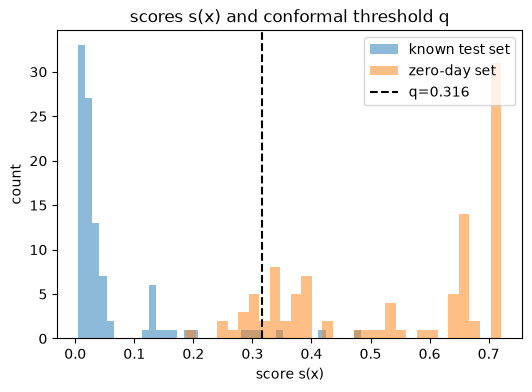

In [27]:
plt.figure(figsize=(6,4))
plt.hist(novelty_scores, bins=40, alpha=0.5, label="known test set")
plt.hist(scores_zero, bins=30, alpha=0.5, label="zero-day set")
plt.axvline(q, color="k", linestyle="--", label=f"q={q:.3f}")
plt.legend()
plt.xlabel("score s(x)")
plt.ylabel("count")
plt.title("scores s(x) and conformal threshold q")
plt.show()

## Logging

In [28]:
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

# publish artifact
artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "lphi_path": str(lphi_path) if lphi_path else None,
    "q_source": q_source,
    "q": float(q),
    "alpha": float(alpha),
    "L_phi": float(L_phi),
    "p": float(p),
    "C_f": float(Cf),
    "pipeline_reject_rate": float(pipeline_reject_rate),
    "pipeline_acc_accepted": float(pipeline_acc),
    "pipeline_macro_f1_accepted": float(pipeline_macro_f1),
    "pipeline_radius_mean_accepted": float(pipeline_radius_mean),
    "zeroday_detection_rate": float(detection_rate),
    "n_zeroday_eval": int(len(X_zero)),
}
torch.save(artifact, out_dir / f"{NOTEBOOK_NAME}-algo3.pt")
print("published:", (out_dir / f"{NOTEBOOK_NAME}-algo3.pt").resolve())

# write log (final)
write_history_log(
    history if history else {"radius_mean": [pipeline_radius_mean]},
    NOTEBOOK_NAME,
    extra=artifact,
    log_dir="logs",
)

published: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/CICIoT2023/22.e2e-algo3_ciciot2023.ipynb-algo3.pt


PosixPath('logs/22.e2e-algo3_ciciot2023.ipynb.log')